# Phase 30 — Chi-square Feature Selection & Visualization

Χρησιμοποιούμε Chi-square test για να βρούμε ποιες λέξεις είναι πιο
διαγνωστικές για κάθε hazard/product κλάση.

**Τι κάνει το Chi-square:**
Μετράει τη στατιστική εξάρτηση μεταξύ κάθε feature (λέξη) και της κλάσης.
Υψηλό Chi-square score = η λέξη εμφανίζεται πολύ πιο συχνά σε μια κλάση
από ό,τι αναμένεται τυχαία.

**Σκοπός:**
1. Visualization — ποιες λέξεις χαρακτηρίζουν κάθε κλάση
2. Feature selection — χρήση μόνο των top-K features για SVM
3. Σύγκριση performance με/χωρίς feature selection

In [ ]:
#!pip install wordcloud -q

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv('train.csv')
valid = pd.read_csv('valid.csv')
test  = pd.read_csv('test.csv')

def preprocess(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

train['combined'] = train['title'].apply(preprocess) + ' ' + train['text'].str[:550].apply(preprocess)
valid['combined'] = valid['title'].apply(preprocess) + ' ' + valid['text'].str[:550].apply(preprocess)
test['combined']  = test['title'].apply(preprocess)  + ' ' + test['text'].str[:550].apply(preprocess)

# TF-IDF με πολλά features για να έχουμε από τι να επιλέξουμε
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words='english'
)
X_train = tfidf.fit_transform(train['combined'])
X_valid = tfidf.transform(valid['combined'])
X_test  = tfidf.transform(test['combined'])

feature_names = np.array(tfidf.get_feature_names_out())

print(f'Train: {len(train)} | Valid: {len(valid)}')
print(f'TF-IDF features: {X_train.shape[1]:,}')

Train: 5082 | Valid: 565
TF-IDF features: 50,000


In [3]:
def official_st1_score(y_true_hazard, y_pred_hazard,
                       y_true_product, y_pred_product, verbose=True):
    f1_hazard = f1_score(y_true_hazard, y_pred_hazard, average='macro', zero_division=0)
    mask = (np.array(y_true_hazard) == np.array(y_pred_hazard))
    f1_product = f1_score(
        np.array(y_true_product)[mask],
        np.array(y_pred_product)[mask],
        average='macro', zero_division=0
    ) if mask.sum() > 0 else 0.0
    score = (f1_hazard + f1_product) / 2
    if verbose:
        print(f'  macro-F1 Hazard:                    {f1_hazard:.4f}')
        print(f'  Σωστά hazard:                       {mask.sum()}/{len(mask)} ({100*mask.mean():.1f}%)')
        print(f'  macro-F1 Product (given correct h): {f1_product:.4f}')
        print(f'  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
        print(f'  OFFICIAL ST1 SCORE:                 {score:.4f}')
    return score

## 1. Top Features ανά Hazard Κλάση

In [4]:
# Chi-square για hazard
chi2_scores_hazard, _ = chi2(X_train, train['hazard-category'])

# Top 10 features ανά hazard κλάση
hazard_classes = sorted(train['hazard-category'].unique())

print('=== TOP 10 FEATURES ΑΝΑ HAZARD ΚΛΑΣΗ ===\n')
hazard_top_features = {}

for cls in hazard_classes:
    # Chi-square μόνο για αυτή την κλάση (binary)
    y_binary = (train['hazard-category'] == cls).astype(int)
    scores, _ = chi2(X_train, y_binary)
    top_idx = scores.argsort()[-10:][::-1]
    top_words = [(feature_names[i], scores[i]) for i in top_idx]
    hazard_top_features[cls] = top_words

    print(f'{cls}:')
    for word, score in top_words[:5]:
        print(f'  {word:30s} χ²={score:.1f}')
    print()

=== TOP 10 FEATURES ΑΝΑ HAZARD ΚΛΑΣΗ ===

allergens:
  undeclared                     χ²=110.4
  allergen                       χ²=89.3
  allergy                        χ²=74.1
  milk                           χ²=64.4
  intolerance                    χ²=46.9

biological:
  listeria                       χ²=106.9
  salmonella                     χ²=102.6
  monocytogenes                  χ²=87.3
  listeria monocytogenes         χ²=87.2
  coli                           χ²=49.9

chemical:
  ethylene                       χ²=131.7
  ethylene oxide                 χ²=131.7
  oxide                          χ²=131.7
  pesticide                      χ²=104.8
  unauthorised                   χ²=91.2

food additives and flavourings:
  mini jelly                     χ²=359.3
  jelly cups                     χ²=352.3
  konjac                         χ²=343.0
  jelly                          χ²=264.0
  containing konjac              χ²=228.9

foreign bodies:
  pieces                         χ²=142.0

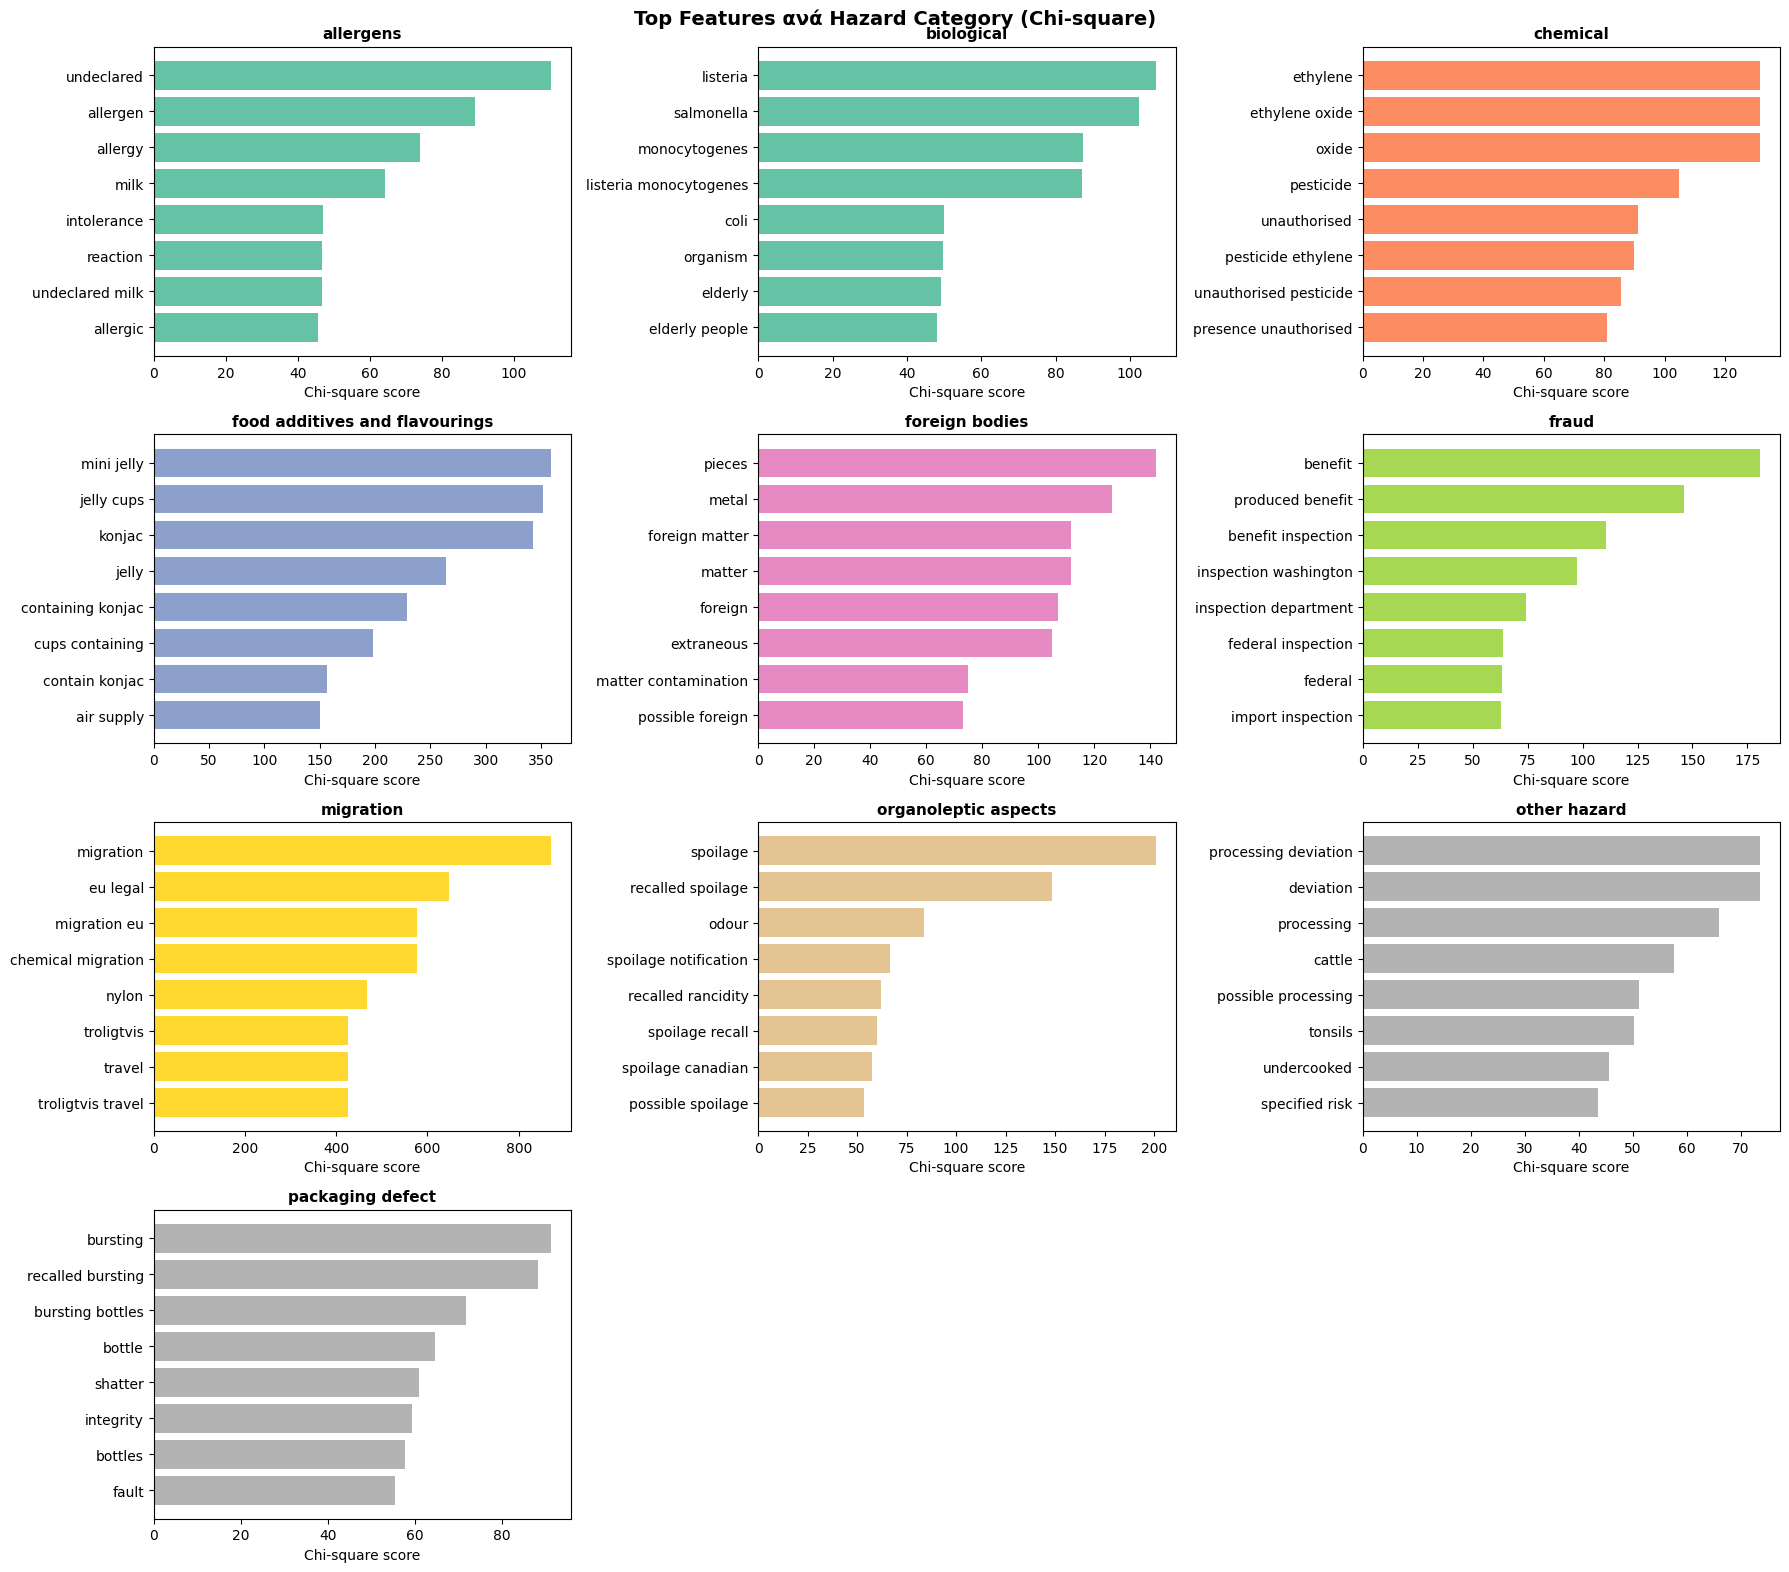

Αποθηκεύτηκε: chi2_hazard_features.png


In [5]:
# Visualization: Bar charts top features ανά hazard κλάση
n_classes = len(hazard_classes)
n_cols    = 3
n_rows    = (n_classes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()
colors = plt.cm.Set2(np.linspace(0, 1, n_classes))

for i, cls in enumerate(hazard_classes):
    words, scores = zip(*hazard_top_features[cls][:8])
    axes[i].barh(words[::-1], scores[::-1], color=colors[i])
    axes[i].set_title(f'{cls}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Chi-square score')

# Κρύψε τα άδεια subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top Features ανά Hazard Category (Chi-square)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chi2_hazard_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Αποθηκεύτηκε: chi2_hazard_features.png')

## 2. Top Features ανά Product Κλάση

=== TOP 5 FEATURES ΑΝΑ PRODUCT ΚΛΑΣΗ (Top 10) ===

meat, egg and dairy products:
  beef                           χ²=79.6
  fsis                           χ²=53.2
  establishment                  χ²=50.6
  agriculture food               χ²=49.6
  inspection service             χ²=49.5

cereals and bakery products:
  bakery                         χ²=53.9
  cookies                        χ²=48.9
  cake                           χ²=42.3
  bread                          χ²=41.3
  flour                          χ²=34.8

fruits and vegetables:
  enoki                          χ²=40.4
  dried                          χ²=37.3
  sprouts                        χ²=34.1
  mushroom                       χ²=33.9
  alfalfa                        χ²=26.4

prepared dishes and snacks:
  potato                         χ²=38.2
  potato chips                   χ²=34.8
  sandwiches                     χ²=25.4
  spring rolls                   χ²=21.1
  potato salad                   χ²=16.6

seafood:
  salm

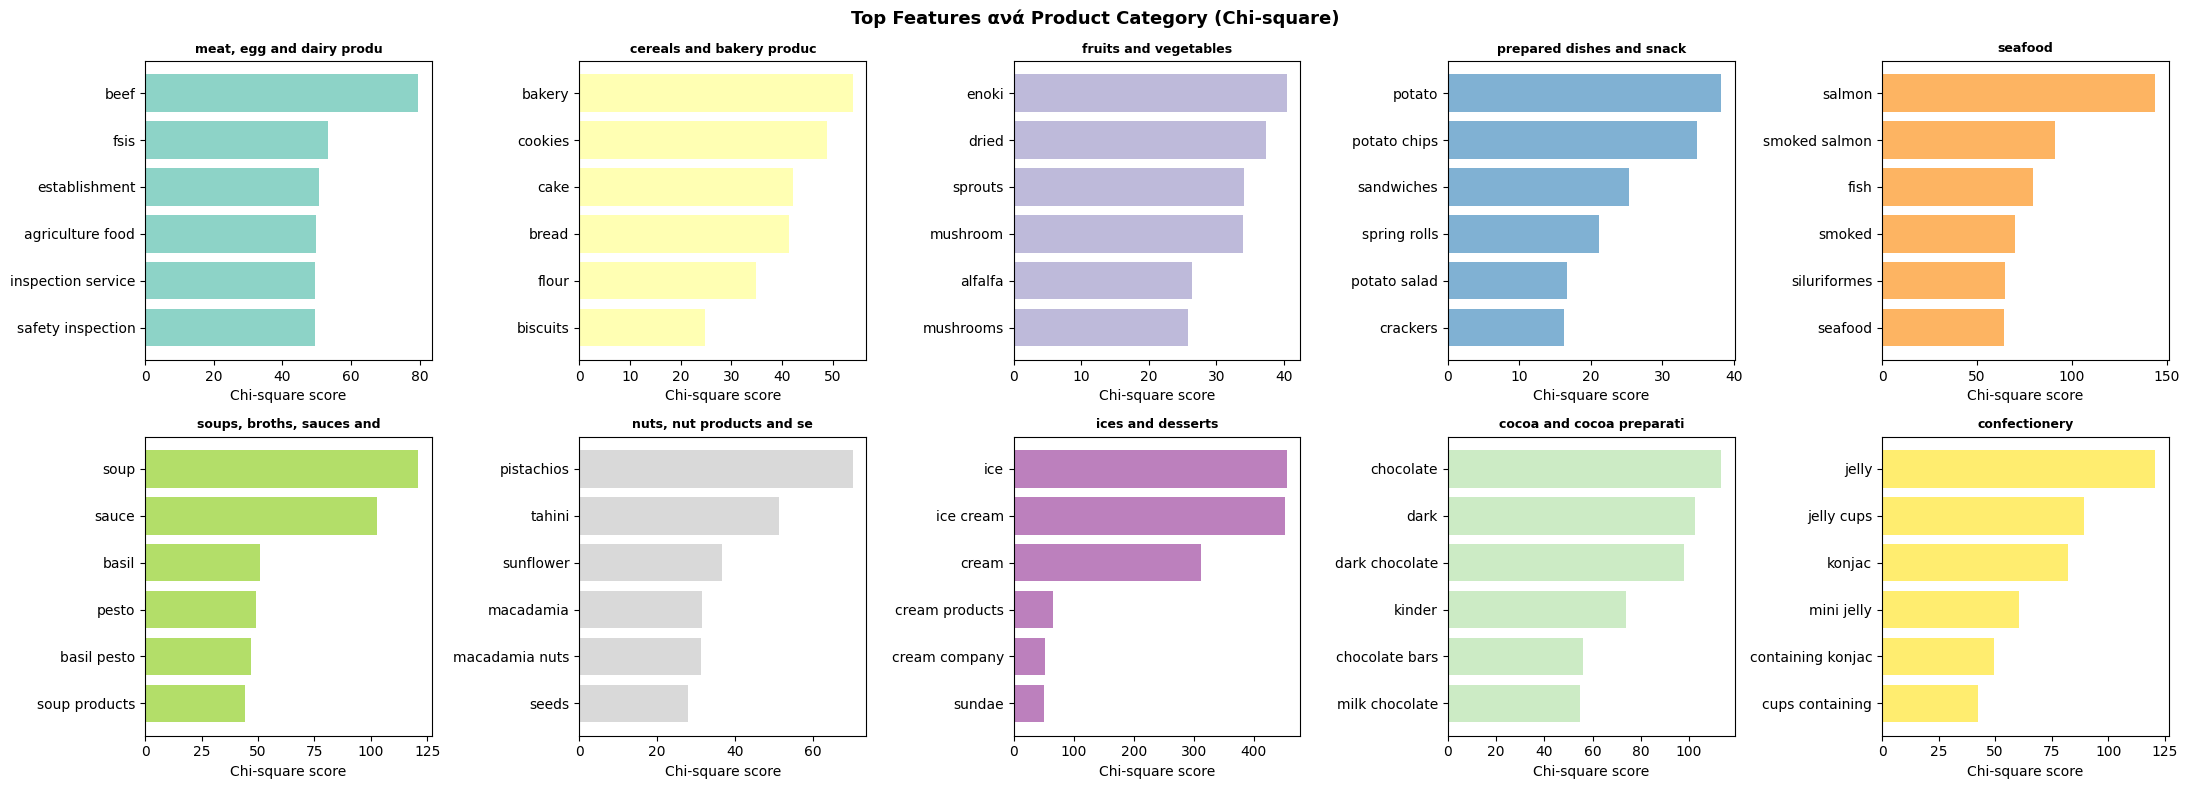

Αποθηκεύτηκε: chi2_product_features.png


In [6]:
# Top 5 features για τις 10 πιο συχνές product κλάσεις
top10_products = train['product-category'].value_counts().head(10).index.tolist()
product_top_features = {}

print('=== TOP 5 FEATURES ΑΝΑ PRODUCT ΚΛΑΣΗ (Top 10) ===\n')
for cls in top10_products:
    y_binary = (train['product-category'] == cls).astype(int)
    scores, _ = chi2(X_train, y_binary)
    top_idx = scores.argsort()[-10:][::-1]
    top_words = [(feature_names[i], scores[i]) for i in top_idx]
    product_top_features[cls] = top_words

    print(f'{cls}:')
    for word, score in top_words[:5]:
        print(f'  {word:30s} χ²={score:.1f}')
    print()

# Bar chart
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
colors = plt.cm.Set3(np.linspace(0, 1, 10))

for i, cls in enumerate(top10_products):
    words, scores = zip(*product_top_features[cls][:6])
    axes[i].barh(words[::-1], scores[::-1], color=colors[i])
    axes[i].set_title(cls[:25], fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Chi-square score')

plt.suptitle('Top Features ανά Product Category (Chi-square)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chi2_product_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Αποθηκεύτηκε: chi2_product_features.png')

## 3. Word Clouds ανά Hazard Κλάση

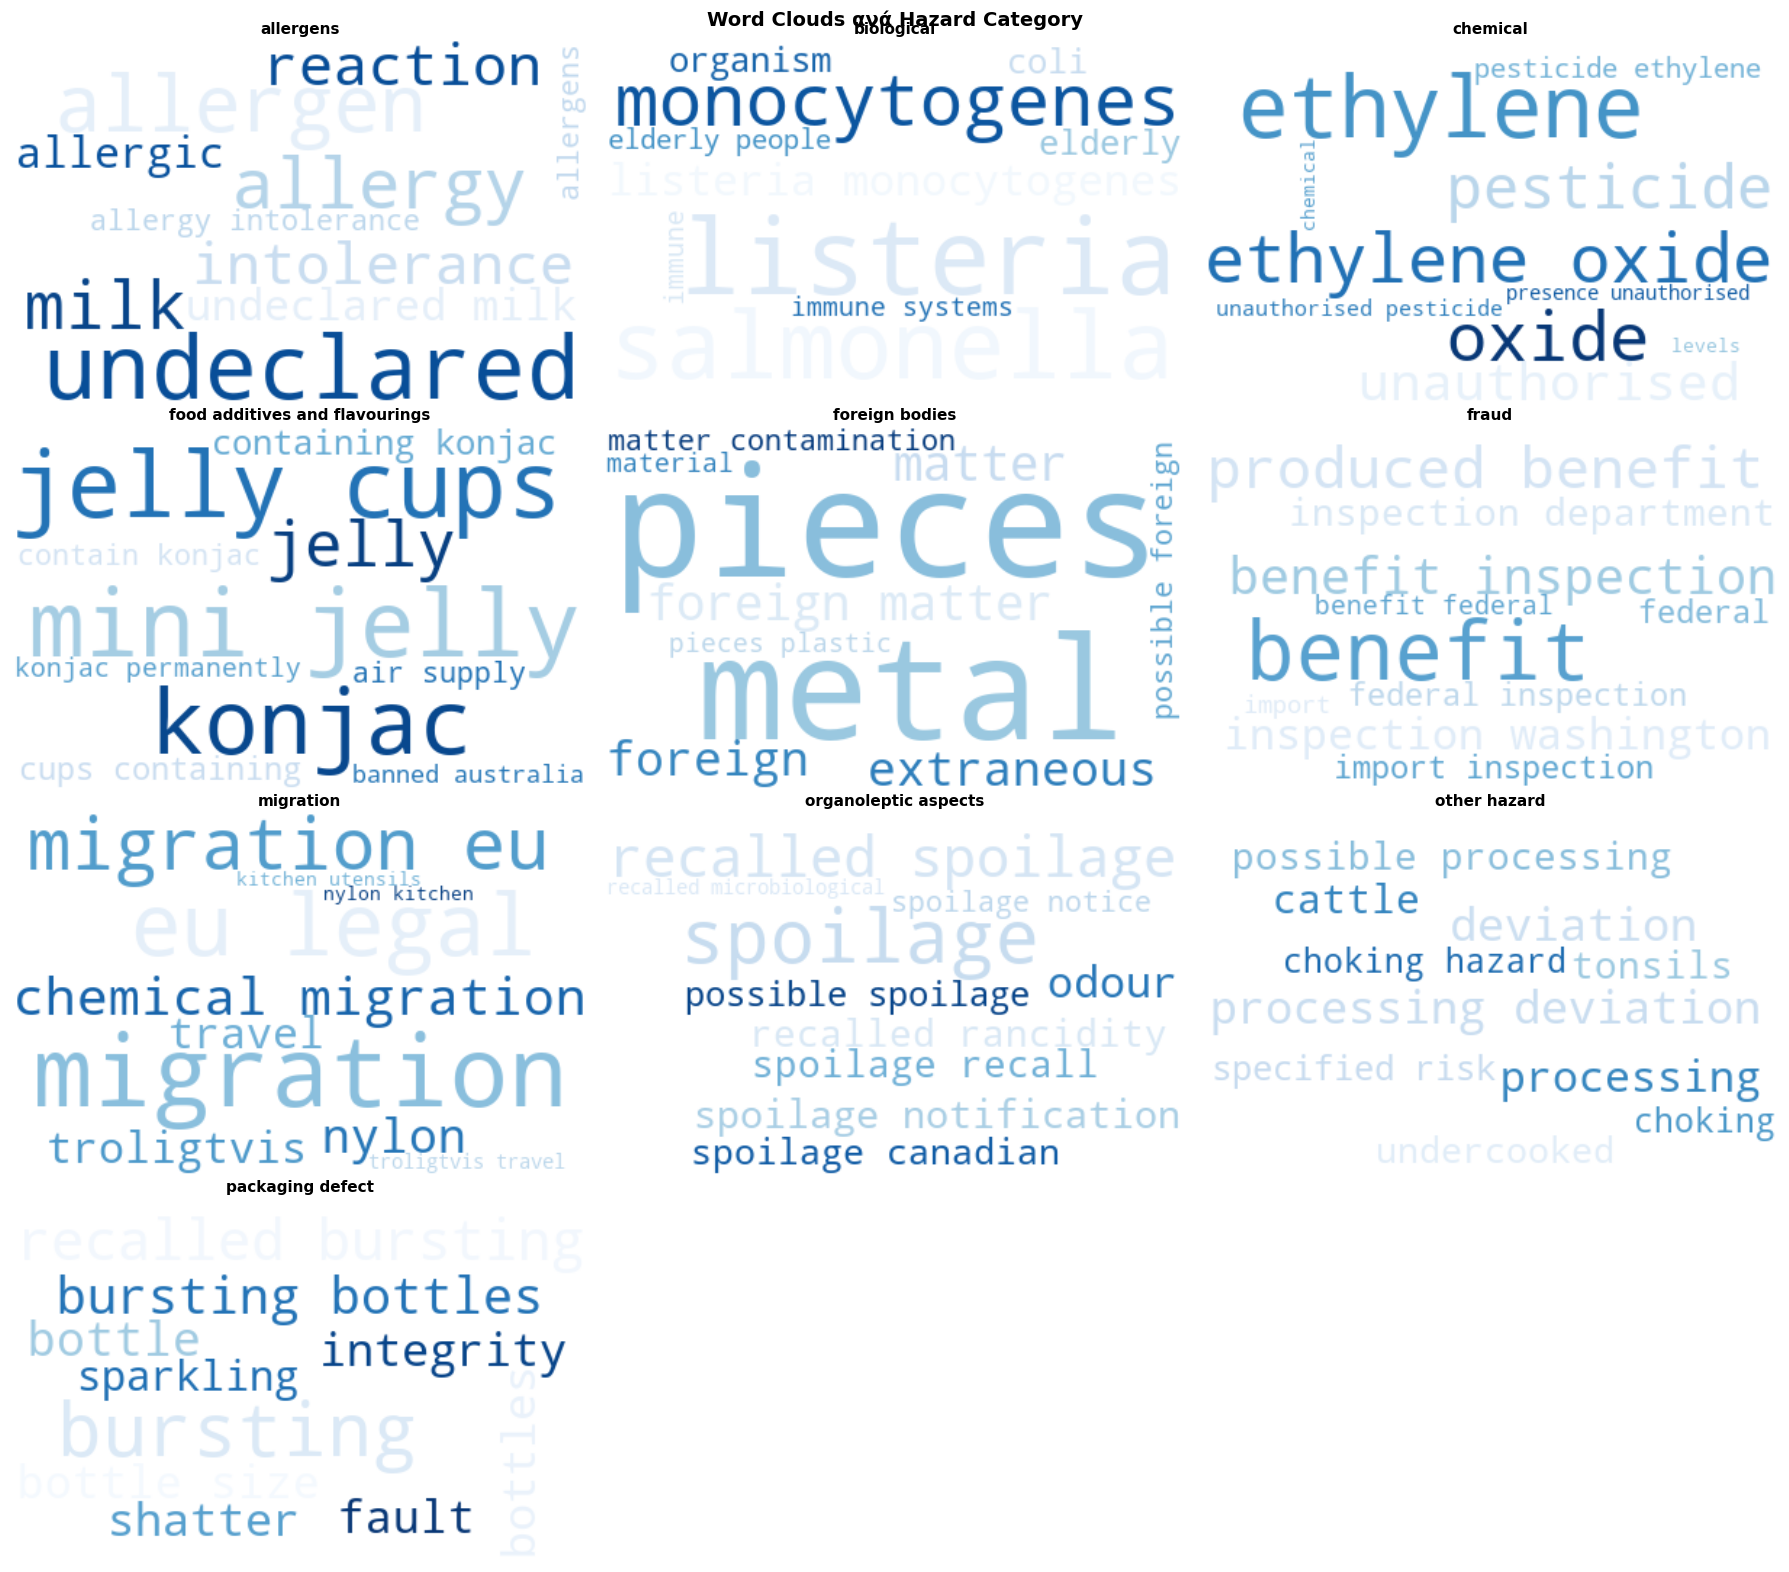

Αποθηκεύτηκε: wordclouds_hazard.png


In [7]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, cls in enumerate(hazard_classes):
    word_freq = {word: score for word, score in hazard_top_features[cls]}
    wc = WordCloud(
        width=400, height=250,
        background_color='white',
        colormap='Blues',
        max_words=30
    ).generate_from_frequencies(word_freq)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(cls, fontsize=11, fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Word Clouds ανά Hazard Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds_hazard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Αποθηκεύτηκε: wordclouds_hazard.png')

## 4. Feature Selection — Σύγκριση SVM με διαφορετικό αριθμό features

=== FEATURE SELECTION — SVM με διαφορετικό K ===

K=  1000: F1 Hazard=0.7385 | F1 Product=0.4927
K=  5000: F1 Hazard=0.7817 | F1 Product=0.6708
K= 10000: F1 Hazard=0.8001 | F1 Product=0.6958
K= 20000: F1 Hazard=0.8006 | F1 Product=0.6974
K= 50000: F1 Hazard=0.8040 | F1 Product=0.6979


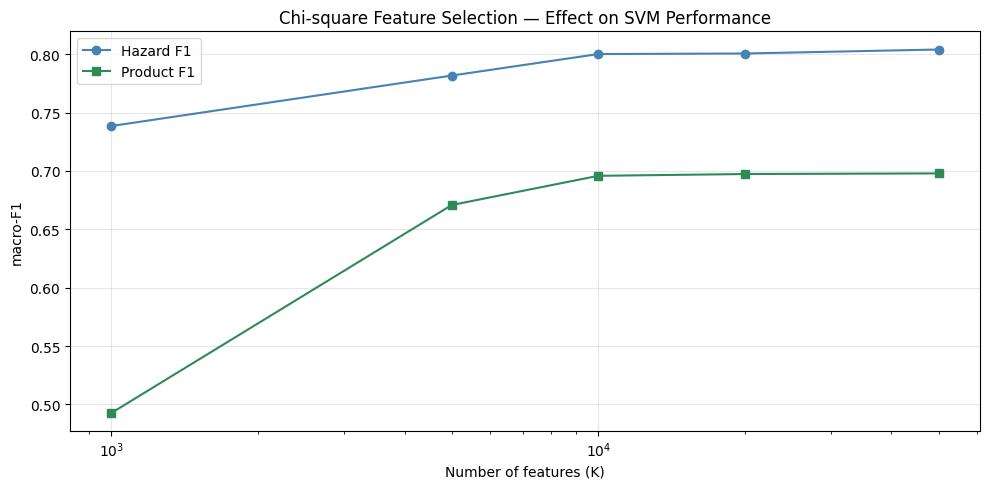


Αποθηκεύτηκε: feature_selection_curve.png


In [8]:
k_values = [1000, 5000, 10000, 20000, 50000]
scores_hazard_k  = []
scores_product_k = []

print('=== FEATURE SELECTION — SVM με διαφορετικό K ===\n')

for k in k_values:
    # Chi-square feature selection
    selector_h = SelectKBest(chi2, k=min(k, X_train.shape[1]))
    X_train_k_h = selector_h.fit_transform(X_train, train['hazard-category'])
    X_valid_k_h = selector_h.transform(X_valid)

    selector_p = SelectKBest(chi2, k=min(k, X_train.shape[1]))
    X_train_k_p = selector_p.fit_transform(X_train, train['product-category'])
    X_valid_k_p = selector_p.transform(X_valid)

    # SVM
    clf_h = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)
    clf_h.fit(X_train_k_h, train['hazard-category'])
    pred_h = clf_h.predict(X_valid_k_h)
    f1_h = f1_score(valid['hazard-category'], pred_h, average='macro', zero_division=0)

    clf_p = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)
    clf_p.fit(X_train_k_p, train['product-category'])
    pred_p = clf_p.predict(X_valid_k_p)
    f1_p = f1_score(valid['product-category'], pred_p, average='macro', zero_division=0)

    scores_hazard_k.append(f1_h)
    scores_product_k.append(f1_p)
    print(f'K={k:6d}: F1 Hazard={f1_h:.4f} | F1 Product={f1_p:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values, scores_hazard_k,  marker='o', label='Hazard F1',  color='steelblue')
ax.plot(k_values, scores_product_k, marker='s', label='Product F1', color='seagreen')
ax.set_xlabel('Number of features (K)')
ax.set_ylabel('macro-F1')
ax.set_title('Chi-square Feature Selection — Effect on SVM Performance')
ax.legend()
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('feature_selection_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nΑποθηκεύτηκε: feature_selection_curve.png')

## 5. Mutual Information (σύγκριση με Chi-square)

In [9]:
from sklearn.feature_selection import mutual_info_classif

print('=== MUTUAL INFORMATION vs CHI-SQUARE ===\n')

# Mutual Information για hazard
mi_scores = mutual_info_classif(X_train, train['hazard-category'], random_state=42)
top_mi_idx = mi_scores.argsort()[-15:][::-1]

print('Top 15 features (Mutual Information — Hazard):')
for idx in top_mi_idx:
    print(f'  {feature_names[idx]:30s} MI={mi_scores[idx]:.4f}')

# Σύγκριση: ποια features συμφωνούν και ποια διαφέρουν
top_chi2_set = set(feature_names[chi2_scores_hazard.argsort()[-15:][::-1]])
top_mi_set   = set(feature_names[top_mi_idx])

print(f'\nΚοινά features (Chi-square ∩ MI): {top_chi2_set & top_mi_set}')
print(f'Μόνο Chi-square: {top_chi2_set - top_mi_set}')
print(f'Μόνο MI:         {top_mi_set - top_chi2_set}')

=== MUTUAL INFORMATION vs CHI-SQUARE ===

Top 15 features (Mutual Information — Hazard):
  product                        MI=1.0953
  recall                         MI=0.9026
  products                       MI=0.8818
  food                           MI=0.7921
  recalling                      MI=0.7601
  date                           MI=0.7259
  recalls                        MI=0.6503
  undeclared                     MI=0.5062
  recalled                       MI=0.4336
  best                           MI=0.4286
  safety                         MI=0.4247
  possible                       MI=0.4149
  risk                           MI=0.3934
  inspection                     MI=0.3715
  food safety                    MI=0.3694

Κοινά features (Chi-square ∩ MI): set()
Μόνο Chi-square: {'migration eu', 'fiskars', 'nylon', 'legal limit', 'troligtvis travel', 'chemical migration', 'kitchen utensils', 'troligtvis', 'mini jelly', 'travel', 'jelly cups', 'eu legal', 'migration', 'konjac', 'nylon

In [10]:
print('\n=== ΣΥΝΟΨΗ ===')
print('Αρχεία που αποθηκεύτηκαν:')
print('  chi2_hazard_features.png    — Top features ανά hazard κλάση')
print('  chi2_product_features.png   — Top features ανά product κλάση')
print('  wordclouds_hazard.png       — Word clouds ανά hazard κλάση')
print('  feature_selection_curve.png — Performance vs number of features')
print('\nΒασικά ευρήματα για αναφορά:')
print(f'  Best K για hazard:  {k_values[np.argmax(scores_hazard_k)]}')
print(f'  Best K για product: {k_values[np.argmax(scores_product_k)]}')
print(f'  Max F1 hazard:  {max(scores_hazard_k):.4f}')
print(f'  Max F1 product: {max(scores_product_k):.4f}')


=== ΣΥΝΟΨΗ ===
Αρχεία που αποθηκεύτηκαν:
  chi2_hazard_features.png    — Top features ανά hazard κλάση
  chi2_product_features.png   — Top features ανά product κλάση
  wordclouds_hazard.png       — Word clouds ανά hazard κλάση
  feature_selection_curve.png — Performance vs number of features

Βασικά ευρήματα για αναφορά:
  Best K για hazard:  50000
  Best K για product: 50000
  Max F1 hazard:  0.8040
  Max F1 product: 0.6979
